In [1]:
import os
import gc
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from tqdm import tqdm
import warnings
from kaggle_secrets import UserSecretsClient

In [2]:
#Конфигурация
BASE_MODEL = "sberbank-ai/rugpt3medium_based_on_gpt2"
ADAPTER_REPO = "nikrog/rugpt3medium_finetuned_psychology"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROMPT = "Клиент испытывает тревожность перед экзаменами. Какие техники релаксации можно порекомендовать?"

In [3]:
user_secrets = UserSecretsClient()
HGF_TOKEN = user_secrets.get_secret("HF_TOKEN")
login(token=HGF_TOKEN)

In [4]:
# Функция замера
def measure_generation(**gen_kwargs):
    inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
    input_len = inputs["input_ids"].shape[1]
    
    if DEVICE == "cuda":
        torch.cuda.synchronize()
        
    start = time.perf_counter()
    with torch.no_grad():
        output = model.generate(
            **inputs,
            **gen_kwargs,
            pad_token_id=tokenizer.eos_token_id,
            return_dict_in_generate=True,
            output_scores=False
        )
    if DEVICE == "cuda":
        torch.cuda.synchronize()
        
    total_time = time.perf_counter() - start
    generated_tokens = output.sequences.shape[1] - input_len
    
    return {
        "total_time_sec": round(total_time, 4),
        "generated_tokens": generated_tokens,
        "tokens_per_sec": round(generated_tokens / total_time, 2) if total_time > 0 else 0
    }

In [5]:
def measure_generation_without_model_init(**gen_kwargs):
    inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
    input_len = inputs["input_ids"].shape[1]
    
    # 1. Warmup: прогреваем GPU, аллоцируем память, компилируем ядра
    _ = model.generate(
        **inputs, max_new_tokens=10, do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    
    # 2. Усреднение по нескольким прогонам
    n_runs = 3
    total_times = []
    
    for _ in range(n_runs):
        if DEVICE == "cuda":
            torch.cuda.synchronize()
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()
            
        start = time.perf_counter()
        with torch.no_grad():
            output = model.generate(
                **inputs, **gen_kwargs,
                pad_token_id=tokenizer.eos_token_id,
                return_dict_in_generate=True,
                output_scores=False
            )
            
        if DEVICE == "cuda":
            end_event.record()
            torch.cuda.synchronize()
            total_times.append(start_event.elapsed_time(end_event) / 1000.0)
        else:
            total_times.append(time.perf_counter() - start)
            
    generated_tokens = output.sequences.shape[1] - input_len
    avg_time = sum(total_times) / len(total_times)
    
    return {
        "total_time_sec": round(avg_time, 4),
        "generated_tokens": generated_tokens,
        "tokens_per_sec": round(generated_tokens / avg_time, 2) if avg_time > 0 else 0
    }

In [6]:
print("Загрузка базовой модели...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    device_map="auto",
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    low_cpu_mem_usage=True
)

print("Загрузка адаптера и слияние...")
peft_model = PeftModel.from_pretrained(base_model, ADAPTER_REPO)
model = peft_model.merge_and_unload()
model.eval()

# Очистка памяти после слияния
if DEVICE == "cuda":
    gc.collect()
    torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_REPO)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Модель готова на {DEVICE}. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Загрузка базовой модели...


config.json:   0%|          | 0.00/761 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/1.73G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


adapter_model.safetensors:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Модель готова на cuda. VRAM: 0.51 GB


In [7]:
# Сетка параметров
param_grid = {
    "max_new_tokens": [50, 100, 150, 200],
    "num_beams": [1, 3, 5],
    "do_sample": [False, True],
    "temperature": [0.5, 0.7, 1.0],
    "top_k": [None, 50]
}

results = []
print("\n Запуск экспериментов...")
total_runs = (len(param_grid["max_new_tokens"]) * len(param_grid["num_beams"]) * 
              len(param_grid["do_sample"]) * len(param_grid["temperature"]) * len(param_grid["top_k"]))

with tqdm(total=total_runs, desc="Прогресс") as pbar:
    for max_new_tokens in param_grid["max_new_tokens"]:
        for num_beams in param_grid["num_beams"]:
            for do_sample in param_grid["do_sample"]:
                for temperature in ([1.0] if not do_sample else param_grid["temperature"]):
                    for top_k in param_grid["top_k"]:
                        if top_k is not None and not do_sample:
                            pbar.update(1)
                            continue
                            
                        config = {
                            "max_new_tokens": max_new_tokens,
                            "num_beams": num_beams,
                            "do_sample": do_sample,
                            "temperature": temperature,
                            "use_cache": True
                        }
                        if top_k is not None:
                            config["top_k"] = top_k
                            
                        try:
                            metrics = measure_generation_without_model_init(**config)
                            results.append({**config, **metrics})
                            pbar.set_postfix(tok_s=metrics["tokens_per_sec"])
                        except Exception as e:
                            print(f"\nОшибка при {config}: {e}")
                        pbar.update(1)

df = pd.DataFrame(results)
df.to_csv("rugpt3medium_peft_benchmark.csv", index=False)
print(f"\nГотово! {len(df)} комбинаций сохранено.")


 Запуск экспериментов...


Прогресс:  67%|██████▋   | 96/144 [13:55<06:57,  8.70s/it, tok_s=37.7]


Готово! 84 комбинаций сохранено.


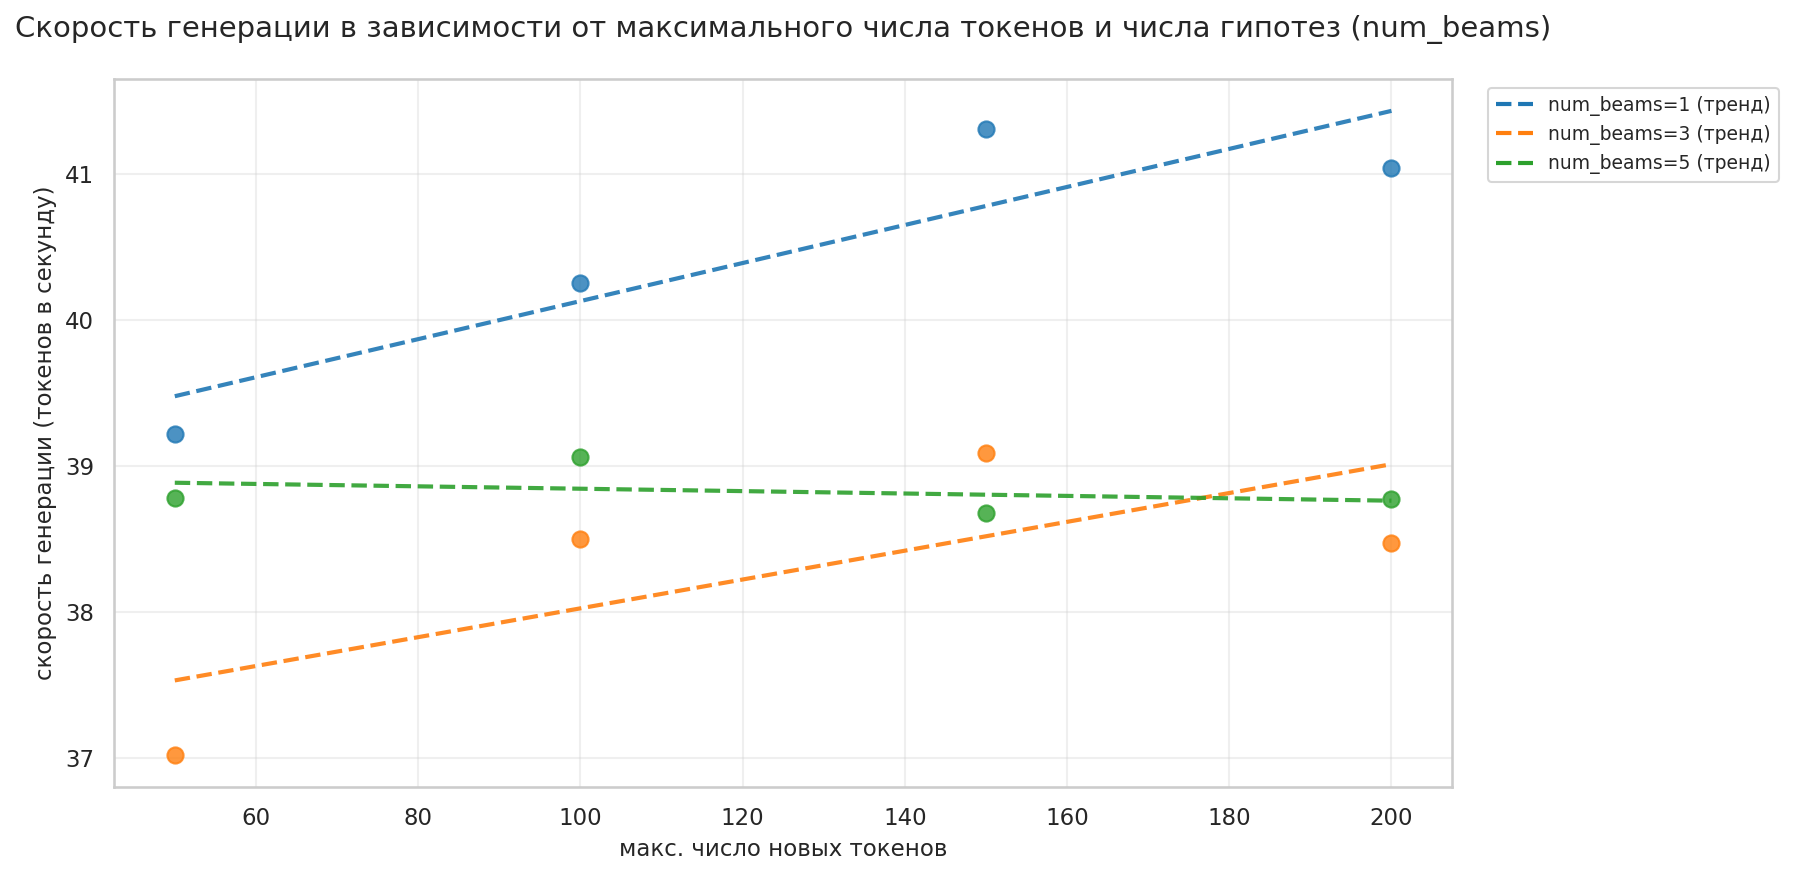

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

# Фильтруем данные для наглядности (опционально)
plot_df = df[df["do_sample"] == False].copy()  # или True, или оба варианта отдельно

plt.figure(figsize=(12, 6))

# Цветовая палитра для num_beams
palette = sns.color_palette("tab10", n_colors=len(plot_df["num_beams"].unique()))

# Строим точки + линейную регрессию для каждой группы (num_beams)
for idx, beams in enumerate(sorted(plot_df["num_beams"].unique())):
    subset = plot_df[plot_df["num_beams"] == beams]
    
    # Scatter: исходные точки
    plt.scatter(subset["max_new_tokens"], subset["tokens_per_sec"], 
                label=f"num_beams={beams} (данные)", 
                color=palette[idx], s=60, alpha=0.8, zorder=5)
    
    # Linear fit: аппроксимация
    x = subset["max_new_tokens"].values
    y = subset["tokens_per_sec"].values
    if len(x) >= 2:  # Для регрессии нужно минимум 2 точки
        coeffs = np.polyfit(x, y, deg=1)  # Линейная: y = a*x + b
        poly = np.poly1d(coeffs)
        x_smooth = np.linspace(x.min(), x.max(), 100)
        plt.plot(x_smooth, poly(x_smooth), 
                 label=f"num_beams={beams} (тренд)", 
                 color=palette[idx], linestyle="--", linewidth=2, alpha=0.9)

plt.title("Скорость генерации в зависимости от максимального числа токенов и числа гипотез (num_beams)", fontsize=14, pad=20)
plt.xlabel("макс. число новых токенов", fontsize=11)
plt.ylabel("скорость генерации (токенов в секунду)", fontsize=11)

# Кастомный легенд: показываем только тренды, чтобы не загромождать
handles = [Line2D([0], [0], color=palette[idx], linestyle="--", linewidth=2, 
                  label=f"num_beams={beams} (тренд)") 
           for idx, beams in enumerate(sorted(plot_df["num_beams"].unique()))]
plt.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("speed_vs_params_with_trend.png", dpi=300, bbox_inches='tight')
plt.show()

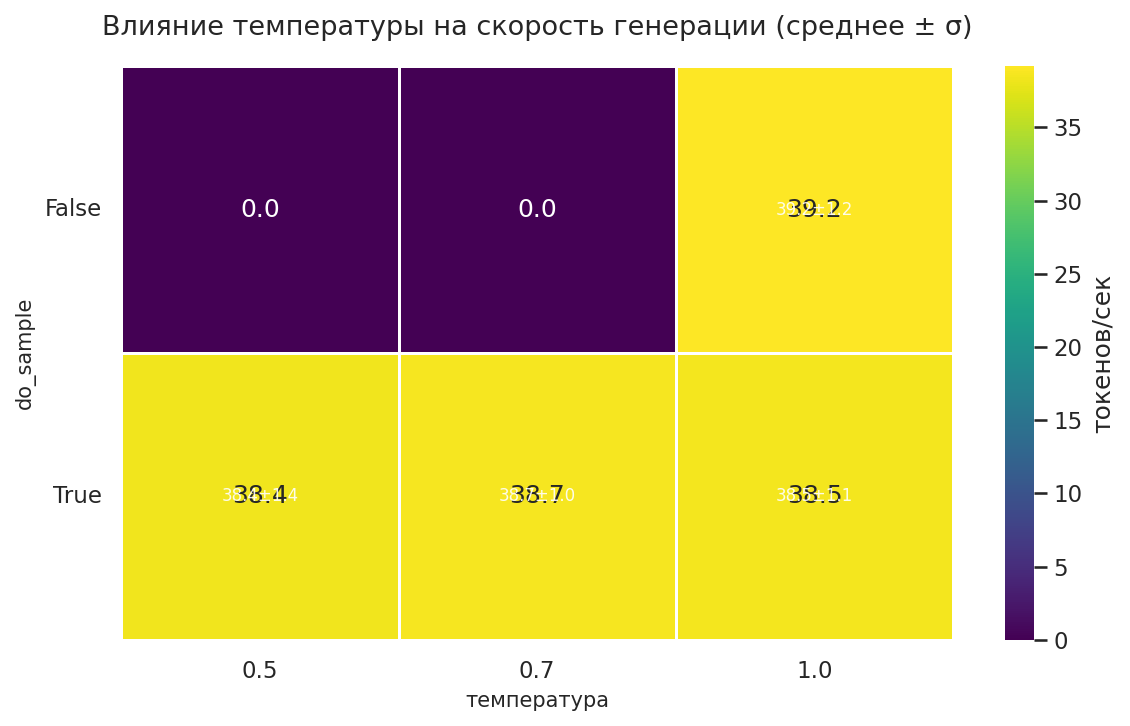

In [9]:
# Тепловая карта: среднее + стандартное отклонение для надёжности
pivot_mean = df.pivot_table(values="tokens_per_sec", index="do_sample", 
                            columns="temperature", aggfunc="mean", fill_value=0)
pivot_std = df.pivot_table(values="tokens_per_sec", index="do_sample", 
                           columns="temperature", aggfunc="std", fill_value=0)

plt.figure(figsize=(8, 5))

# Основная карта: средние значения
ax = sns.heatmap(pivot_mean, annot=True, fmt=".1f", cmap="viridis", 
                 cbar_kws={'label': 'токенов/сек'}, linewidths=0.5)

# Добавляем ±σ мелким шрифтом под основным значением
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        mean_val = pivot_mean.iloc[i, j]
        std_val = pivot_std.iloc[i, j]
        if not np.isnan(std_val) and std_val > 0:
            # Добавляем подпись с отклонением
            text = f"{mean_val:.1f}±{std_val:.1f}"
            ax.text(j + 0.5, i + 0.5, text, ha="center", va="center", 
                    fontsize=8, color="white", alpha=0.9)

plt.title("Влияние температуры на скорость генерации (среднее ± σ)", fontsize=13, pad=15)
plt.xlabel("температура", fontsize=10)
plt.ylabel("do_sample", fontsize=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("temp_vs_speed_with_std.png", dpi=300, bbox_inches='tight')
plt.show()

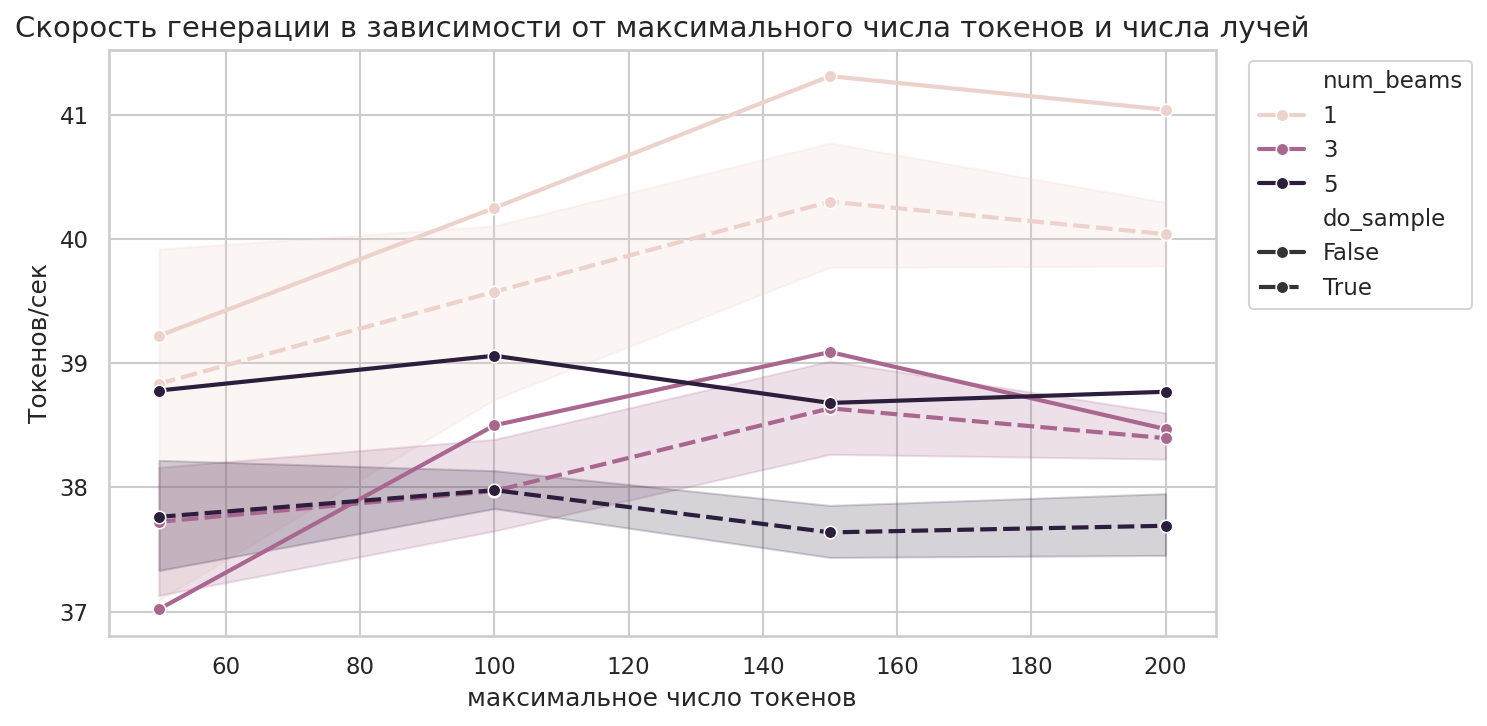

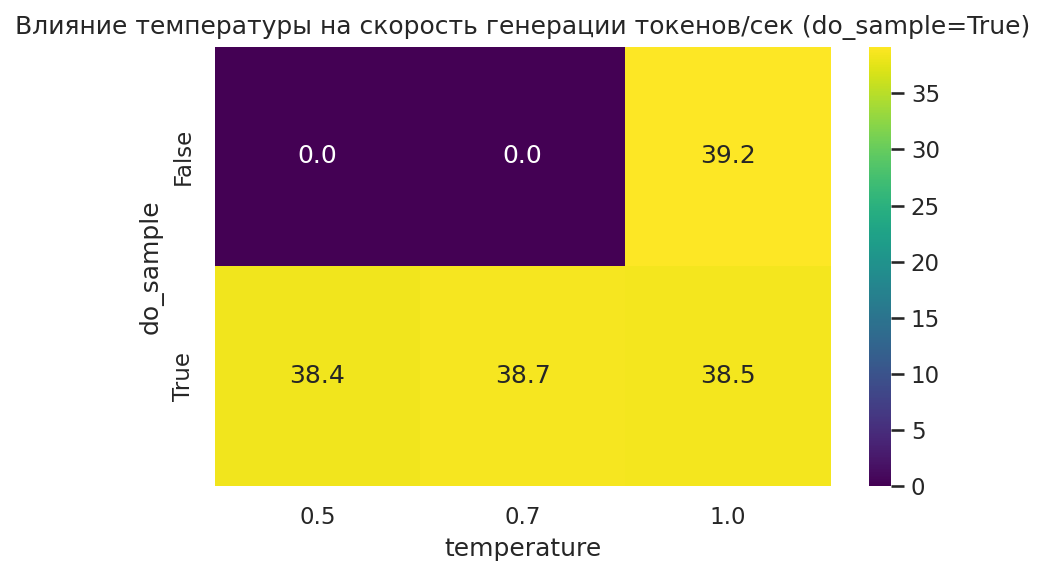

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

# 1. Скорость от длины вывода и лучей
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="max_new_tokens", y="tokens_per_sec", 
             hue="num_beams", style="do_sample", marker="o", linewidth=2)
plt.title("Скорость генерации в зависимости от максимального числа токенов и числа лучей", fontsize=14)
plt.xlabel("максимальное число токенов"); plt.ylabel("Токенов/сек")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("speed_vs_params.png", dpi=300)
plt.show()

# 2. Тепловая карта: влияние сэмплирования
pivot = df.pivot_table(values="tokens_per_sec", index="do_sample", 
                       columns="temperature", aggfunc="mean", fill_value=0)
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="viridis")
plt.title("Влияние температуры на скорость генерации токенов/сек (do_sample=True)")
plt.tight_layout()
plt.savefig("temp_vs_speed.png", dpi=300)
plt.show()